In [101]:
import matplotlib.pyplot as plt
import json
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

In [102]:
test1 = json.load(open("./result_100000_5_2.json", "r"))

projection = np.matrix([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

In [103]:
points = {}
for p in test1["points"]:
    cluster = p["cluster"]
    if cluster not in points:
        points[cluster] = []
    points[cluster].append([p["x"], p["y"], p["z"]])
    
for cluster in points:
    points[cluster] = np.array(points[cluster])
sum = 0
for cluster in points:
    sum += len(points[cluster])
    print(f"[{cluster}] : {len(points[cluster])}")
print(f"=> {sum}")

[0] : 25163
[4] : 12514
[3] : 49841
[1] : 12482
=> 100000


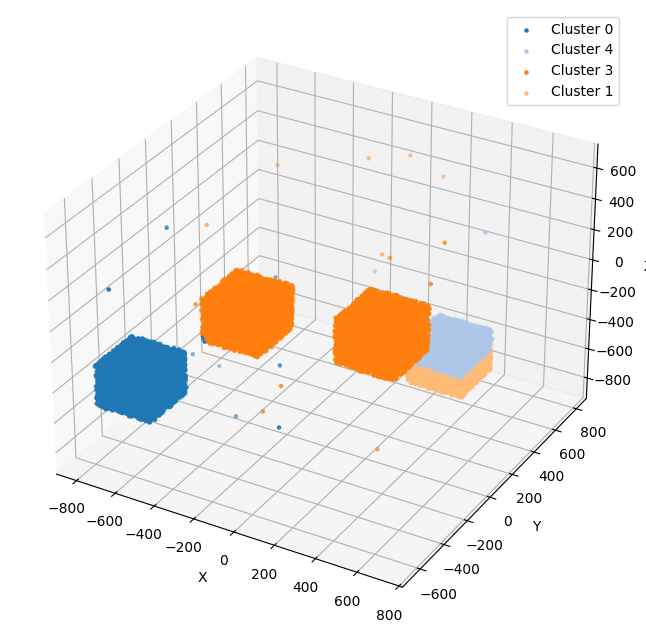

In [104]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

cmap = plt.get_cmap("tab20")

for i, (cluster, pts) in enumerate(points.items()):
    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        pts[:, 2],
        color=cmap(i % 20),
        s=5,
        label=f"Cluster {cluster}"
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.legend()

plt.show()
